In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_ai4i = pd.read_csv('../data/ai4i+2020+predictive+maintenance+dataset/ai4i2020.csv')

print(df_ai4i.shape)
df_ai4i.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df_ai4i.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
df_ai4i.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
print(df_ai4i['Machine failure'].value_counts())
print(df_ai4i['Machine failure'].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [6]:
failure_types = df_ai4i[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()
print(failure_types)

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [7]:
# Nombre de pannes où au moins un sous-type est actif
sous_type_actif = df_ai4i[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum(axis=1) > 0
print("Pannes avec au moins 1 sous-type actif:", sous_type_actif.sum())
print("Machine failure = 1:", (df_ai4i['Machine failure'] == 1).sum())

# Pièces avec Machine failure=1 mais AUCUN sous-type actif (cas limite/RNF pur)
incoherent = df_ai4i[(df_ai4i['Machine failure'] == 1) & (~sous_type_actif)]
print("Cas Machine failure=1 sans sous-type identifié:", len(incoherent))

Pannes avec au moins 1 sous-type actif: 348
Machine failure = 1: 339
Cas Machine failure=1 sans sous-type identifié: 9


In [8]:
print(df_ai4i['Type'].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


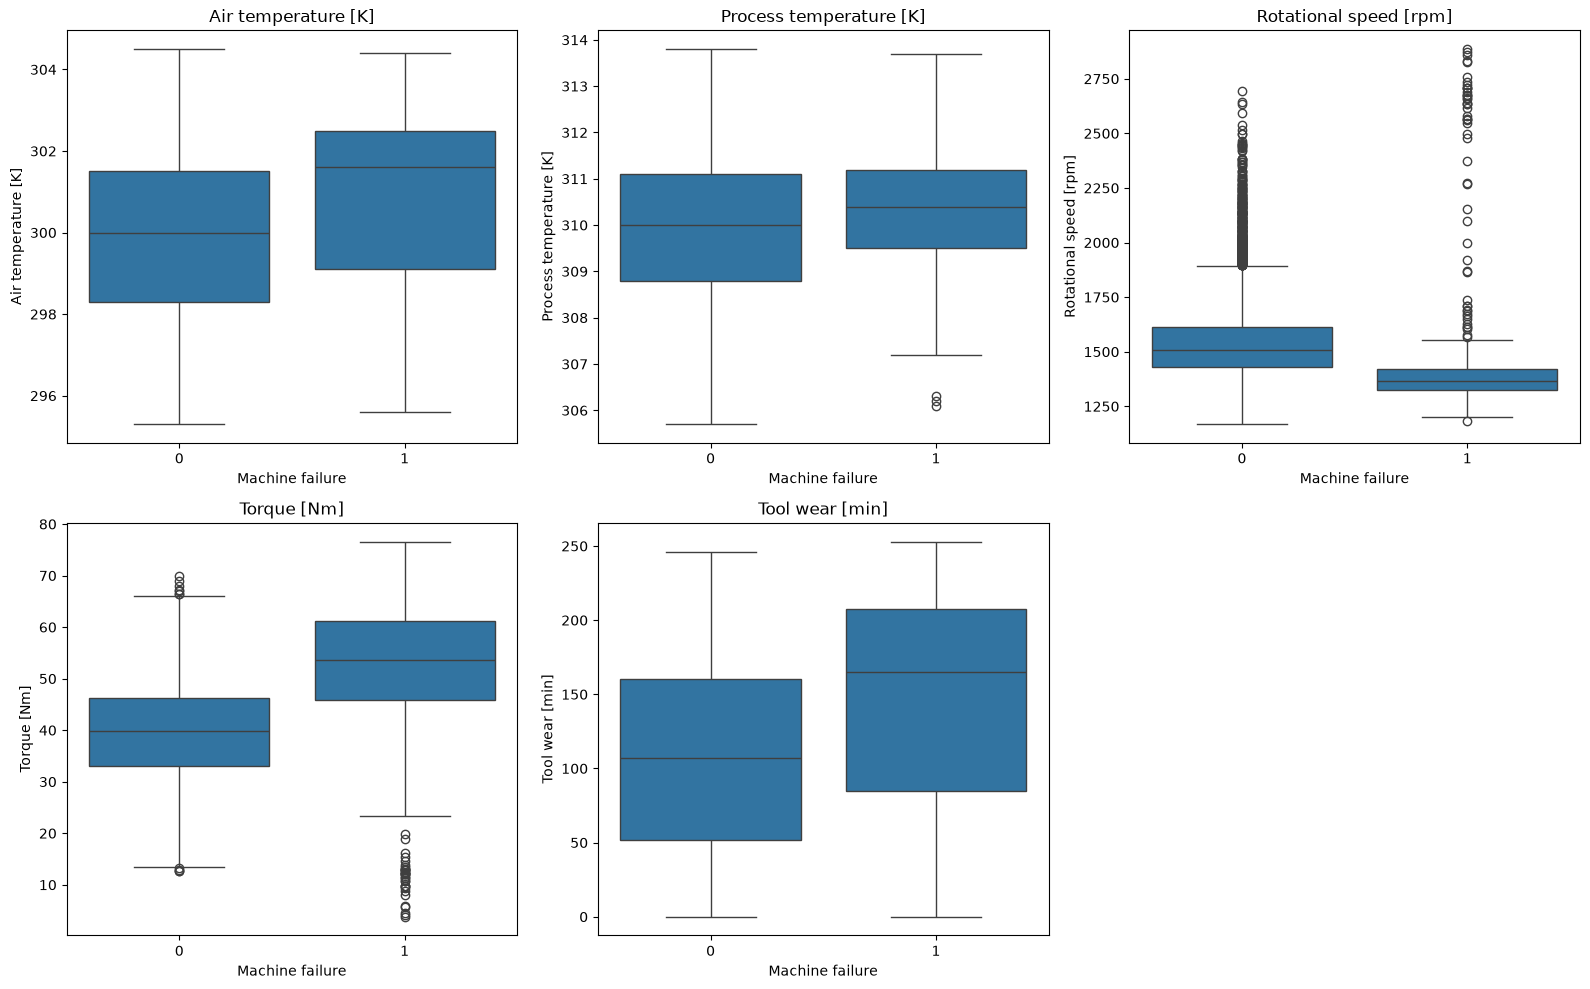

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
features_num = ['Air temperature [K]', 'Process temperature [K]', 
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for i, feat in enumerate(features_num):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df_ai4i, x='Machine failure', y=feat, ax=ax)
    ax.set_title(feat)

axes[1,2].axis('off')  # case vide (5 features pour 6 emplacements)
plt.tight_layout()
plt.show()


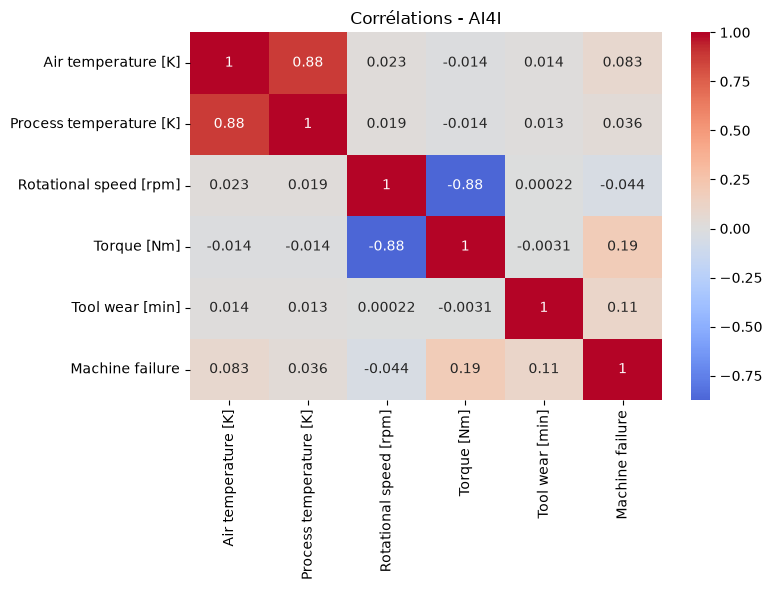

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.54      0.76      0.63        68

    accuracy                           0.97      2000
   macro avg       0.77      0.87      0.81      2000
weighted avg       0.98      0.97      0.97      2000

F1-macro: 0.8092525242249294
AUC: 0.9774273839970771

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.81      0.75        68

    accuracy                           0.98      2000
   macro avg       0.85      0.90      0.87      2000
weighted avg       0.98      0.98      0.98      2000

F1-macro: 0.872041856530486
AUC: 0.9642857142857143

Feature importance:
 Rotational speed [rpm]     0.343366
Torque [Nm]                0.264230
Tool wear [min]            0.198590
Type_encoded               0.082774
Air temperature [K]        0.066235


In [10]:
# --- Corrélation rapide ---
plt.figure(figsize=(8,6))
corr_ai4i = df_ai4i[features_num + ['Machine failure']].corr()
sns.heatmap(corr_ai4i, annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations - AI4I')
plt.tight_layout()
plt.show()

# --- Préparation ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

df_ai4i_ml = df_ai4i.copy()
le_type = LabelEncoder()
df_ai4i_ml['Type_encoded'] = le_type.fit_transform(df_ai4i_ml['Type'])

feature_cols = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_encoded']

X_ai4i = df_ai4i_ml[feature_cols]
y_ai4i = df_ai4i_ml['Machine failure']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_ai4i, y_ai4i, test_size=0.2, random_state=42, stratify=y_ai4i
)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

smote = SMOTE(random_state=42)
X_train_c_bal, y_train_c_bal = smote.fit_resample(X_train_c_scaled, y_train_c)

# --- Entraînement ---
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

rf_c = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_c.fit(X_train_c_bal, y_train_c_bal)
y_pred_rf_c = rf_c.predict(X_test_c_scaled)
y_proba_rf_c = rf_c.predict_proba(X_test_c_scaled)[:,1]

xgb_c = XGBClassifier(n_estimators=200, max_depth=5, random_state=42, eval_metric='logloss')
xgb_c.fit(X_train_c_bal, y_train_c_bal)
y_pred_xgb_c = xgb_c.predict(X_test_c_scaled)
y_proba_xgb_c = xgb_c.predict_proba(X_test_c_scaled)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test_c, y_pred_rf_c))
print("F1-macro:", f1_score(y_test_c, y_pred_rf_c, average='macro'))
print("AUC:", roc_auc_score(y_test_c, y_proba_rf_c))

print("\n=== XGBoost ===")
print(classification_report(y_test_c, y_pred_xgb_c))
print("F1-macro:", f1_score(y_test_c, y_pred_xgb_c, average='macro'))
print("AUC:", roc_auc_score(y_test_c, y_proba_xgb_c))

# --- Feature importance ---
importances_c = pd.Series(xgb_c.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFeature importance:\n", importances_c)

# --- Sauvegarde ---
import joblib
best_model_c = rf_c if f1_score(y_test_c, y_pred_rf_c, average='macro') > f1_score(y_test_c, y_pred_xgb_c, average='macro') else xgb_c
joblib.dump(best_model_c, '../models/module_c_equipment_classifier.pkl')
joblib.dump(scaler_c, '../models/module_c_scaler.pkl')
joblib.dump(le_type, '../models/module_c_type_encoder.pkl')
print("\nModèle Module C sauvegardé.")

In [11]:
print(importances_c)


Rotational speed [rpm]     0.343366
Torque [Nm]                0.264230
Tool wear [min]            0.198590
Type_encoded               0.082774
Air temperature [K]        0.066235
Process temperature [K]    0.044804
dtype: float32
